# Ejemplo con generador GANs


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf


# print(plt.style.available) #list of available styles
plt.style.use("ggplot")

warnings.simplefilter(action="ignore", category=FutureWarning)

start_date = '1990-01-01' (9036, 241)

start_date = '1900-01-01' (16077, 23)



In [2]:
start_date = '1945-01-01'

filepath = 'https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python-2023/main/Tema_5_APT/data/sp500_tickers.csv'
tickers_sp500 = list(pd.read_csv(filepath))

precios_close = yf.download(tickers_sp500, start=start_date, auto_adjust=True, progress=True)['Close']

precios_close.dropna(axis=1, inplace=True)

[****                   9%                       ]  45 of 503 completed$PXD: possibly delisted; no timezone found
[******                12%                       ]  58 of 503 completed$BRK.B: possibly delisted; no timezone found
[******                13%                       ]  65 of 503 completed$IPG: possibly delisted; no timezone found
[*******               15%                       ]  77 of 503 completed$HOLX: possibly delisted; no timezone found
[*********             19%                       ]  97 of 503 completed$CTLT: possibly delisted; no timezone found
[*********             19%                       ]  98 of 503 completed$WRK: possibly delisted; no timezone found
[**********            21%                       ]  108 of 503 completed$CDAY: possibly delisted; no timezone found
[***********           22%                       ]  109 of 503 completed$MMC: possibly delisted; no timezone found
[*****************     35%                       ]  175 of 503 completed$BF.B: po

In [3]:
precios_close.dropna(axis=1, inplace=True)

In [4]:
returns = np.log(precios_close).diff().dropna()
returns.shape

(16246, 23)

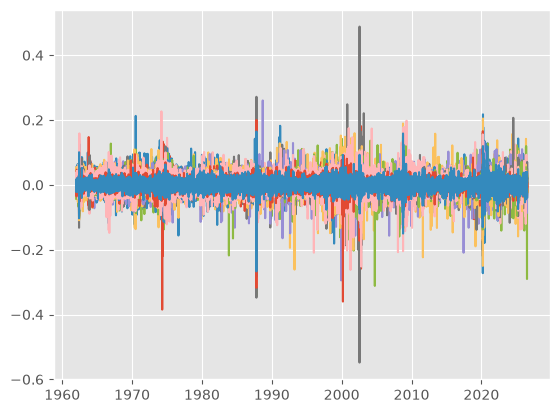

In [5]:
plt.plot(returns)

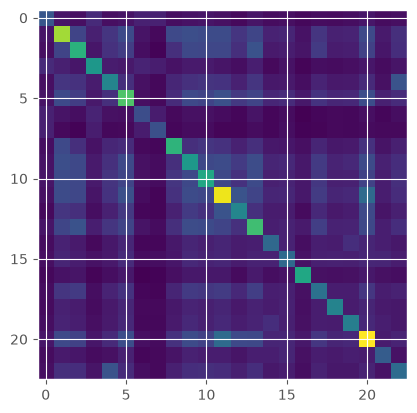

In [6]:
plt.imshow(np.cov(returns.T))

## Definir Parámetros de Ventana

### Subtask:
Establecer las longitudes de las ventanas para X (60 días) y para Y (N días, con un valor predeterminado de 30 días, que el usuario podrá modificar fácilmente).


**Reasoning**:
Define the window sizes for X and Y datasets as specified in the instructions. `window_size_Y` is made easily modifiable.



In [7]:
window_size_X = 60
window_size_Y = 30

print(f"Window size for X: {window_size_X} days")
print(f"Window size for Y (default): {window_size_Y} days")

Window size for X: 60 days
Window size for Y (default): 30 days


**Reasoning**:
Generate the `X` and `Y` datasets by iterating through the `returns` DataFrame, creating 60-day historical return windows for `X` and averaging the subsequent `window_size_Y` days for `Y`, then converting them to NumPy arrays.



In [8]:
X_data = []
Y_data = []

# Ensure there is enough data for both X and Y windows
# The loop goes up to len(returns) - window_size_Y to ensure a full Y window can be extracted
for i in range(window_size_X, len(returns) - window_size_Y):
    # X window: 60 days of historical returns
    X_window = returns.iloc[i - window_size_X:i].values
    X_data.append(X_window)

    # Y window: average of the subsequent N days of returns
    Y_window = returns.iloc[i:i + window_size_Y].values
    # Calculate the average of returns for the Y window
    Y_avg = np.mean(Y_window, axis=0) # average each column (ticker) over the window
    Y_data.append(Y_avg)

X = np.array(X_data)
Y = np.array(Y_data)

print(f"Shape of X dataset: {X.shape}")
print(f"Shape of Y dataset: {Y.shape}")

Shape of X dataset: (16156, 60, 23)
Shape of Y dataset: (16156, 23)


In [9]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train_aux, X_test, Y_train_aux, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

X_train, X_val, Y_train, Y_val = train_test_split(X_train_aux, Y_train_aux, test_size=0.1, random_state=42)


# Datos syntheticos GANs

In [10]:
XY_aux = np.zeros((X_train_aux.shape[0],X_train_aux.shape[1]+1,X_train_aux.shape[2]))
XY_aux[:,0:X_train_aux.shape[1],:] = X_train_aux
XY_aux[:,X_train_aux.shape[1],:] = Y_train_aux


In [11]:
XY_aux_flat = XY_aux.reshape(XY_aux.shape[0],XY_aux.shape[1]*XY_aux.shape[2])

XY_aux_flat.shape

(14540, 1403)

## Entrenamiento GAN

In [36]:
from keras.optimizers import Adam

OPTIMZADOR_DISC = Adam()#learning_rate=0.0001, beta_1=0.5, decay=8e-8)
OPTIMZADOR_GEN = Adam()

In [37]:

# Generador
in_shape = XY_aux_flat.shape[1:]

model_gen = Sequential()
model_gen.add(Dense(256, input_shape=(150,),activation='relu'))
model_gen.add(Dense(512,activation='relu'))
model_gen.add(Dense(1024,activation='relu'))
model_gen.add(Dense(in_shape[0], activation='tanh'))
model_gen.summary()
model_gen.compile(loss='binary_crossentropy', optimizer=OPTIMZADOR_DISC)

/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1403)           │     1,438,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,133,627 (8.14 MB)

 Trainable params: 2,133,627 (8.14 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Discriminador

model_Disc = Sequential()
model_Disc.add(Flatten(input_shape = in_shape))
model_Disc.add(Dense(128,activation='relu'))
model_Disc.add(Dense(64,activation='relu'))
model_Disc.add(Dense(1, activation='sigmoid'))
model_Disc.summary()
model_Disc.compile(loss='binary_crossentropy', optimizer=OPTIMZADOR_DISC, metrics=['accuracy'])

/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 1403)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,033 (734.50 KB)

 Trainable params: 188,033 (734.50 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# modelo combinado

model_gan = Sequential()
model_gan.add(model_gen)
model_gan.add(model_Disc)
model_gan.compile(loss='binary_crossentropy', optimizer=OPTIMZADOR_GEN)

model_gan.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 1403)           │     2,133,627 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 1)              │       188,033 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,321,660 (8.86 MB)

 Trainable params: 2,321,660 (8.86 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
in_shape

(1403,)

In [42]:

epochs = 500
batch = 10

# Entrenamiento

DD_loss = np.zeros((epochs,))
GG_loss = np.zeros((epochs,))

ratio = 1

for cnt in range(epochs):

    ## train discriminator
    batch_discr = int(np.round(ratio*batch))
    random_index = np.random.randint(0, len(XY_aux_flat) - np.int64(batch_discr))
    legit_images = XY_aux_flat[random_index : random_index + np.int64(batch_discr)].reshape((np.int64(batch_discr),)+in_shape)

    gen_noise = np.random.normal(0, 1, (int(batch_discr), 150))
    syntetic_images = model_gen.predict(gen_noise)

    x_combined_batch = np.concatenate((legit_images, syntetic_images))
    y_combined_batch = np.concatenate((np.ones((np.int64(batch_discr), 1)), np.zeros((np.int64(batch_discr), 1))))

    d_loss = model_Disc.train_on_batch(x_combined_batch, y_combined_batch)


    # train generator
    batch_gen = int(np.round(batch/ratio))

    noise = np.random.normal(0, 1, (2*batch_gen, 150))
    y_mislabled = np.ones((2*batch_gen, 1))

    g_loss = model_gan.train_on_batch(noise, y_mislabled)

    print ('epoch: %d, [Discriminator :: d_loss: %f], [ Generator :: loss: %f], [ batch dicr :: loss: %f], [ batch gen :: loss: %f]' % (cnt, d_loss[0], g_loss, batch_discr, batch_gen))

    DD_loss[cnt] = d_loss[0]
    GG_loss[cnt] = g_loss
    
    ratio = (DD_loss[cnt]+1)/(GG_loss[cnt]+1)
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
epoch: 0, [Discriminator :: d_loss: 3.066811], [ Generator :: loss: 0.016471], [ batch dicr :: loss: 10.000000], [ batch gen :: loss: 10.000000]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
epoch: 1, [Discriminator :: d_loss: 3.325345], [ Generator :: loss: 0.010490], [ batch dicr :: loss: 40.000000], [ batch gen :: loss: 2.000000]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
epoch: 2, [Discriminator :: d_loss: 3.420433], [ Generator :: loss: 0.010276], [ batch dicr :: loss: 43.000000], [ batch gen :: loss: 2.000000]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
epoch: 3, [Discriminator :: d_loss: 3.222113], [ Generator :: loss: 0.012284], [ batch dicr :: loss: 44.000000], [ batch gen :: loss: 2.000000]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
epoch: 4, [Discriminator :: d_loss: 3.097789], [ Generator :: loss: 0.015878], [ batch dicr :: loss: 42.000000], [ batch gen :: loss: 2.000000]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
epoch: 5, [Discriminator :: d_loss: 2.946473], [ Ge

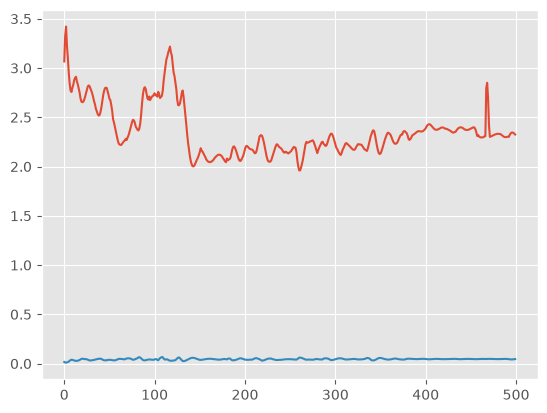

In [ ]:
plt.figure
plt.plot(DD_loss)
plt.plot(GG_loss)

In [45]:
n_muestras = 10000

gen_noise = np.random.normal(0, 1, (int(n_muestras), 150))
XY_synth_flat = model_gen.predict(gen_noise)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [46]:
print(XY_synth_flat.shape)

(10000, 1403)


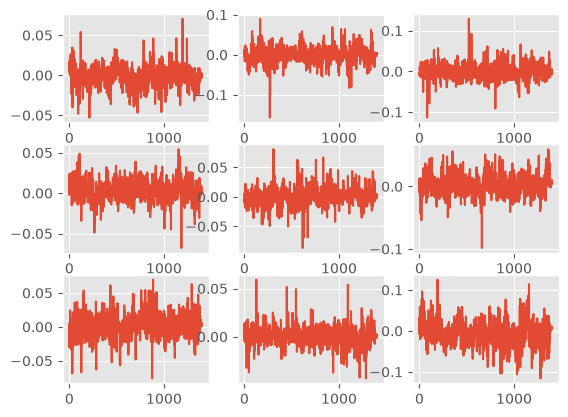

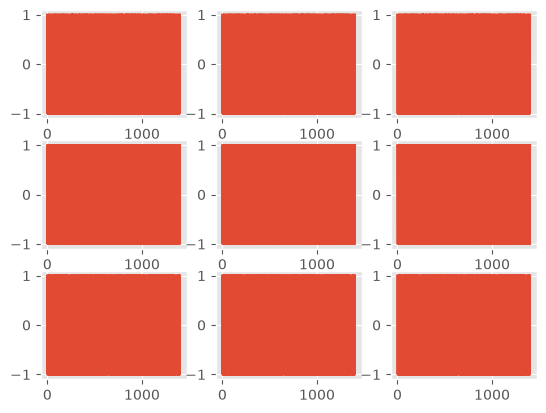

In [47]:
import matplotlib.pyplot as plt

plt.figure()
for n in range(9):
    plt.subplot(3,3,n+1)
    plt.plot(XY_aux_flat[n*10,:].T)


plt.figure()
for n in range(9):
    plt.subplot(3,3,n+1)
    plt.plot(XY_synth_flat[n*10,:].T)

In [17]:
# Reordenamos

XY_synth = np.reshape(XY_synth_flat,[XY_synth_flat.shape[0],XY_aux.shape[1],XY_aux.shape[2]])

XY_synth.shape

(10000, 61, 23)

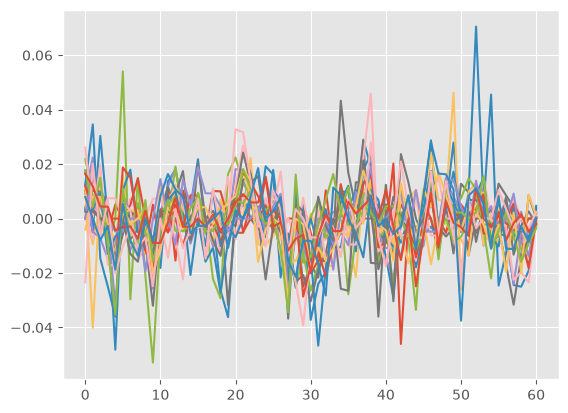

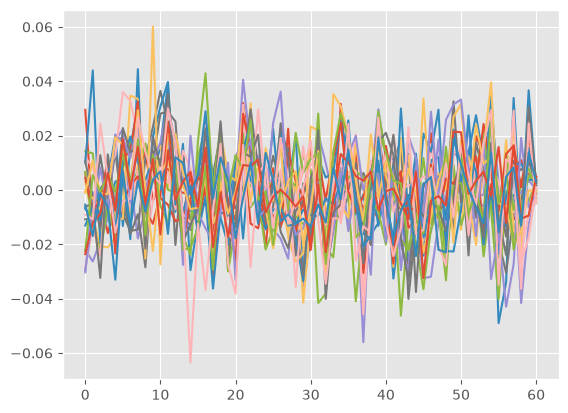

In [18]:

plt.figure()
plt.plot(XY_aux[0])


plt.figure()
plt.plot(XY_synth[0])

In [19]:
# Separamos X e Y 

X_train_aux_synth = XY_synth[:,0:X_train_aux.shape[1],:]
Y_train_aux_synth = XY_synth[:,X_train_aux.shape[1],:]

print(X_train_aux_synth.shape)
print(Y_train_aux_synth.shape)

(10000, 60, 23)
(10000, 23)


In [20]:
X_train_ext = np.concatenate((X_train, X_train_aux_synth), axis=0)
Y_train_ext = np.concatenate((Y_train, Y_train_aux_synth), axis=0)

In [24]:
print(X_train.shape)

(13086, 60, 23)


In [34]:
X_train_ext = np.concatenate((X_train[0:500], X_train_aux_synth[0:1000]), axis=0)
Y_train_ext = np.concatenate((Y_train[0:500], Y_train_aux_synth[0:1000]), axis=0)

print(X_train_ext.shape)
print(Y_train_ext.shape)

(1500, 60, 23)
(1500, 23)


# Entrenamiento con Sintéticos

In [35]:

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming X, Y, X_train, X_test, Y_train, Y_test, loss, mae, baseline_mse, baseline_mae, lr_mse, lr_mae are already defined from previous steps

# Define the CNN model
# X_train shape is (samples, timesteps, features) -> (None, 60, 23)
cnn_model_2 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(Y_train.shape[1]) # Output layer with no activation for regression
])

# Compile the CNN model
cnn_model_2.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the CNN model summary
print("\n--- CNN Model Summary ---")
cnn_model_2.summary()




--- CNN Model Summary ---


/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,887 (565.96 KB)

 Trainable params: 144,887 (565.96 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train the CNN model
print("\nTraining the CNN model...")
history_cnn_2 = cnn_model_2.fit(X_train_ext, Y_train_ext, epochs=100, batch_size=128, validation_data=(X_val,Y_val), verbose=1)




Training the CNN model...
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 2.0694e-05 - mae: 0.0033 - val_loss: 1.1416e-05 - val_mae: 0.0025
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 9.9625e-06 - mae: 0.0024 - val_loss: 1.0177e-05 - val_mae: 0.0023
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.3001e-06 - mae: 0.0023 - val_loss: 9.8675e-06 - val_mae: 0.0023
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 9.1579e-06 - mae: 0.0023 - val_loss: 9.7481e-06 - val_mae: 0.0023
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 9.0617e-06 - mae: 0.0023 - val_loss: 9.6704e-06 - val_mae: 0.0023
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 9.0335e-06 - mae: 0.0023 - val_loss: 9.6367e-06 - val_mae: 0.0022
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 9.0075e-06 - mae: 0.0023 - val_loss: 9.6091e-06 - val_mae: 0.0022
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 8.9891e-06 - mae: 0.0023 - val_

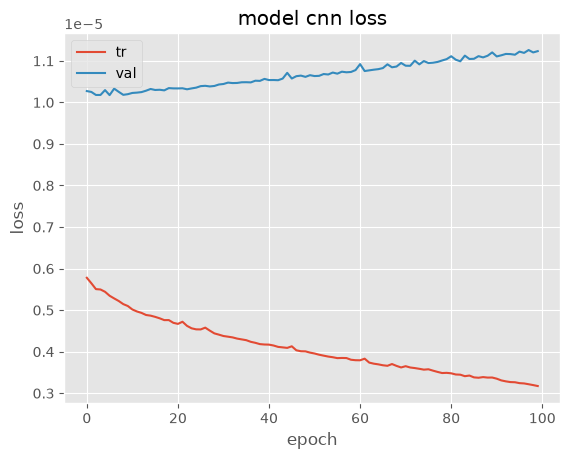

In [ ]:
# Sin datos sinteticos
plt.plot(history_cnn_2.history['loss'],label='tr')
plt.plot(history_cnn_2.history['val_loss'],label='val')
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

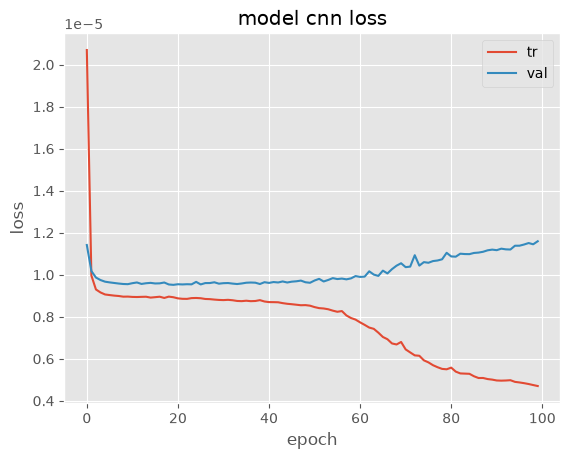

In [37]:
# 1000 datos sintéticos
plt.plot(history_cnn_2.history['loss'],label='tr')
plt.plot(history_cnn_2.history['val_loss'],label='val')
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

In [39]:
X_train_ext = np.concatenate((X_train[0:500], X_train_aux_synth[0:5000]), axis=0)
Y_train_ext = np.concatenate((Y_train[0:500], Y_train_aux_synth[0:5000]), axis=0)

print(X_train_ext.shape)
print(Y_train_ext.shape)

(5500, 60, 23)
(5500, 23)


In [40]:

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming X, Y, X_train, X_test, Y_train, Y_test, loss, mae, baseline_mse, baseline_mae, lr_mse, lr_mae are already defined from previous steps

# Define the CNN model
# X_train shape is (samples, timesteps, features) -> (None, 60, 23)
cnn_model_2 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(Y_train.shape[1]) # Output layer with no activation for regression
])

# Compile the CNN model
cnn_model_2.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the CNN model summary
print("\n--- CNN Model Summary ---")
cnn_model_2.summary()


--- CNN Model Summary ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,887 (565.96 KB)

 Trainable params: 144,887 (565.96 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train the CNN model
print("\nTraining the CNN model...")
history_cnn_2 = cnn_model_2.fit(X_train_ext, Y_train_ext, epochs=100, batch_size=128, validation_data=(X_val,Y_val), verbose=1)




Training the CNN model...
Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.1959e-05 - mae: 0.0026 - val_loss: 9.9410e-06 - val_mae: 0.0023
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.1366e-06 - mae: 0.0024 - val_loss: 9.7050e-06 - val_mae: 0.0023
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 9.1006e-06 - mae: 0.0023 - val_loss: 9.6465e-06 - val_mae: 0.0022
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.0699e-06 - mae: 0.0023 - val_loss: 9.6035e-06 - val_mae: 0.0022
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 9.0605e-06 - mae: 0.0023 - val_loss: 9.5639e-06 - val_mae: 0.0022
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 9.0594e-06 - mae: 0.0023 - val_loss: 9.5802e-06 - val_mae: 0.0022
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.0428e-06 - mae: 0.0023 - val_loss: 9.5542e-06 - val_mae: 0.0022
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.0172e-06 - mae: 0.0023 - val_

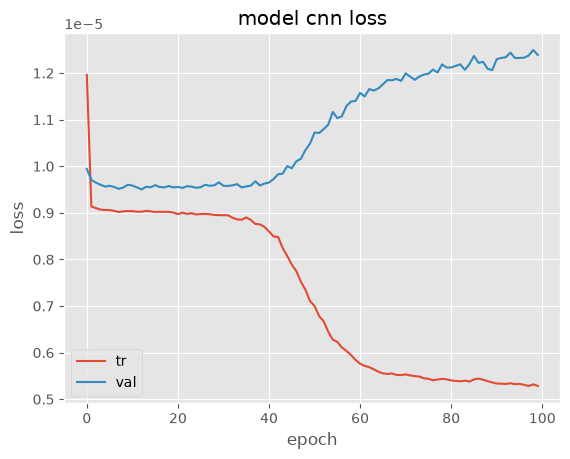

In [42]:
# 5000 datos sintéticos
plt.plot(history_cnn_2.history['loss'],label='tr')
plt.plot(history_cnn_2.history['val_loss'],label='val')
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

# Ejemplo muy tonto (datos con ruido)

In [44]:

# Generamos las muestras
n_muestras = 500
sig = 0.01
Ruido_x = rng.normal(0, sig, X_train[0:n_muestras].shape)
Ruido_y = rng.normal(0, sig, Y_train[0:n_muestras].shape)

X_train_ext = np.concatenate((X_train[0:500], X_train[0:n_muestras]+Ruido_x), axis=0)
Y_train_ext = np.concatenate((Y_train[0:500], Y_train[0:n_muestras]+Ruido_y), axis=0)

print(X_train_ext.shape)
print(Y_train_ext.shape)

(1000, 60, 23)
(1000, 23)


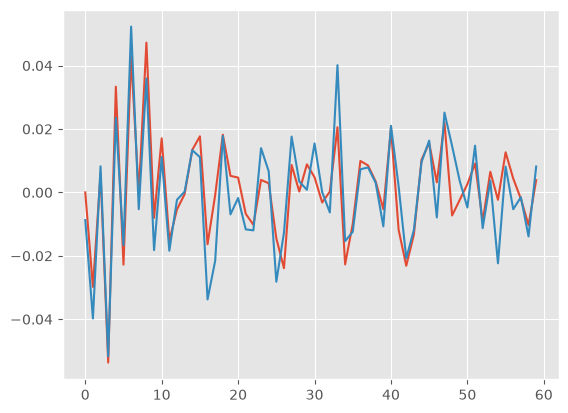

In [45]:
plt.plot(X_train[0,:,0])

plt.plot(X_train[0,:,0]+Ruido_x[0,:,0])

In [46]:

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming X, Y, X_train, X_test, Y_train, Y_test, loss, mae, baseline_mse, baseline_mae, lr_mse, lr_mae are already defined from previous steps

# Define the CNN model
# X_train shape is (samples, timesteps, features) -> (None, 60, 23)
cnn_model_2 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(Y_train.shape[1]) # Output layer with no activation for regression
])

# Compile the CNN model
cnn_model_2.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the CNN model summary
print("\n--- CNN Model Summary ---")
cnn_model_2.summary()


--- CNN Model Summary ---


/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,887 (565.96 KB)

 Trainable params: 144,887 (565.96 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Train the CNN model
print("\nTraining the CNN model...")
history_cnn_2 = cnn_model_2.fit(X_train_ext, Y_train_ext, epochs=100, batch_size=128, validation_data=(X_val,Y_val), verbose=1)




Training the CNN model...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 9.6738e-05 - mae: 0.0071 - val_loss: 1.5896e-05 - val_mae: 0.0030
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 6.3783e-05 - mae: 0.0056 - val_loss: 1.1521e-05 - val_mae: 0.0025
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 6.1178e-05 - mae: 0.0054 - val_loss: 1.0452e-05 - val_mae: 0.0024
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 6.0140e-05 - mae: 0.0053 - val_loss: 1.0166e-05 - val_mae: 0.0023
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 5.9883e-05 - mae: 0.0053 - val_loss: 9.9890e-06 - val_mae: 0.0023
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.9688e-05 - mae: 0.0053 - val_loss: 9.8416e-06 - val_mae: 0.0023
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.9510e-05 - mae: 0.0053 - val_loss: 9.7954e-06 - val_mae: 0.0023
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 5.9425e-05 - mae: 0.0053 - val_loss: 9.8114e-06

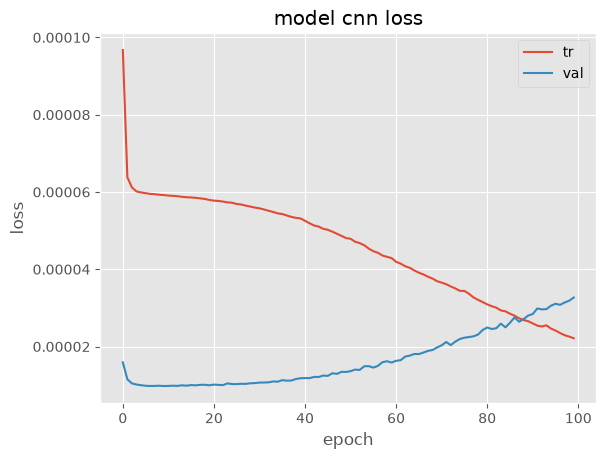

In [48]:
# 500 reales + 500 sintéticos (ruidosos)
plt.plot(history_cnn_2.history['loss'],label='tr')
plt.plot(history_cnn_2.history['val_loss'],label='val')
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

# Entrenar modelo sin sinteticos


In [60]:
cnn_model_1 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(Y_train.shape[1]) # Output layer with no activation for regression
])

# Compile the CNN model
cnn_model_1.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the CNN model summary
print("\n--- CNN Model Summary ---")
cnn_model_1.summary()



--- CNN Model Summary ---


/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,887 (565.96 KB)

 Trainable params: 144,887 (565.96 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Train the CNN model
print("\nTraining the CNN model...")
history_cnn_1 = cnn_model_1.fit(X_train, Y_train, epochs=300, batch_size=32, validation_data=(X_val,Y_val), verbose=1)




Training the CNN model...
Epoch 1/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.5401e-06 - mae: 0.0022 - val_loss: 8.9285e-06 - val_mae: 0.0022
Epoch 2/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.0313e-06 - mae: 0.0022 - val_loss: 8.8898e-06 - val_mae: 0.0022
Epoch 3/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.8416e-06 - mae: 0.0022 - val_loss: 8.5596e-06 - val_mae: 0.0022
Epoch 4/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.4248e-06 - mae: 0.0021 - val_loss: 8.1622e-06 - val_mae: 0.0021
Epoch 5/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.7590e-06 - mae: 0.0021 - val_loss: 7.6394e-06 - val_mae: 0.0021
Epoch 6/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2445e-06 - mae: 0.0020 - val_loss: 7.3884e-06 - val_mae: 0.0020
Epoch 7/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7855e-06 - mae: 0.0019 - val_loss: 6.7878e-06 - val_mae: 0.0019
Epoch 8/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.4563e-06 - mae: 0.00

Text(0.5, 0, 'epoch')

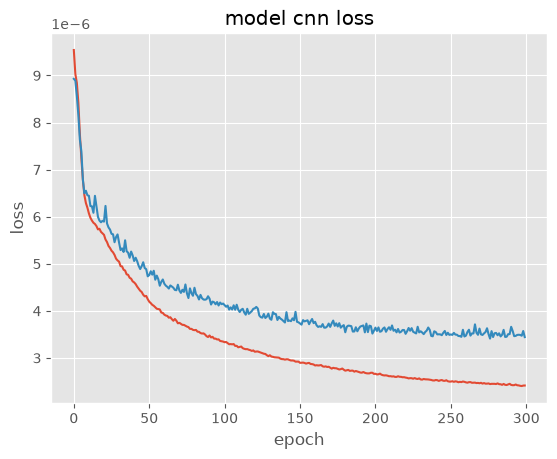

In [62]:
plt.plot(history_cnn_1.history['loss'])
plt.plot(history_cnn_1.history['val_loss'])
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')

In [63]:
# Evaluate the CNN model on the test data

cnn_1_loss, cnn_1_mae = cnn_model_1.evaluate(X_test, Y_test, verbose=0)

print(f"CNN 1 Test Loss (MSE): {cnn_1_loss:.4f}")
print(f"CNN 1 Test Mean Absolute Error (MAE): {cnn_1_mae:.4f}")

print(f"CNN 2 Test Loss (MSE): {cnn_2_loss:.4f}")
print(f"CNN 2 Test Mean Absolute Error (MAE): {cnn_2_mae:.4f}")

CNN 1 Test Loss (MSE): 0.0000
CNN 1 Test Mean Absolute Error (MAE): 0.0014
CNN 2 Test Loss (MSE): 0.0000
CNN 2 Test Mean Absolute Error (MAE): 0.0023
